In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_data.csv'

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
y_reg = df["age"]
y_clf = (y_reg > y_reg.median()).astype(int)

In [ ]:
X = df.drop(columns=["age"])
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_c, X_test_c, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

y_pred = lr.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_reg_test, y_pred))
print("R2:", r2_score(y_reg_test, y_pred))

MSE: 110.37933340495553
R2: 0.3964872937476779


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

y_pred_r = ridge.predict(X_test_scaled)

print("Ridge MSE:", mean_squared_error(y_reg_test, y_pred_r))
print("Ridge R2:", r2_score(y_reg_test, y_pred_r))

Ridge MSE: 110.3792630177065
Ridge R2: 0.3964876785986987


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_clf_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_c = clf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_clf_test, y_pred_c))

              precision    recall  f1-score   support

           0       0.77      0.66      0.71      1701
           1       0.68      0.79      0.73      1613

    accuracy                           0.72      3314
   macro avg       0.73      0.72      0.72      3314
weighted avg       0.73      0.72      0.72      3314



In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_clf_test, y_pred_c))

[[1116  585]
 [ 342 1271]]


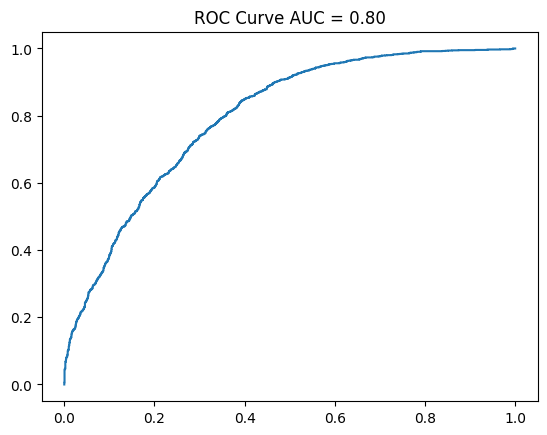

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

proba = clf.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_clf_test, proba)
auc = roc_auc_score(y_clf_test, proba)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve AUC = {auc:.2f}")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    pred = (proba >= t).astype(int)
    print("Threshold:", t,
          "Precision:", precision_score(y_clf_test, pred),
          "Recall:", recall_score(y_clf_test, pred),
          "F1:", f1_score(y_clf_test, pred))

Threshold: 0.3 Precision: 0.639022261021388 Recall: 0.907625542467452 F1: 0.75
Threshold: 0.4 Precision: 0.6538104089219331 Recall: 0.8722876627402356 F1: 0.747410358565737
Threshold: 0.5 Precision: 0.6848060344827587 Recall: 0.7879727216367018 F1: 0.7327760161429807
Threshold: 0.6 Precision: 0.7338289962825278 Recall: 0.6119032858028518 F1: 0.6673427991886409
Threshold: 0.7 Precision: 0.783641160949868 Recall: 0.36825790452572843 F1: 0.5010544074230282


In [ ]:
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import joblib

In [34]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_scaled, y_clf_train)

train_pred = tree.predict(X_train_scaled)
test_pred = tree.predict(X_test_scaled)

print("Train Accuracy:", accuracy_score(y_clf_train, train_pred))
print("Test Accuracy:", accuracy_score(y_clf_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.6412190706095353


In [35]:
tree2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

tree2.fit(X_train_scaled, y_clf_train)

train_pred = tree2.predict(X_train_scaled)
test_pred = tree2.predict(X_test_scaled)

print("Train Accuracy:", accuracy_score(y_clf_train, train_pred))
print("Test Accuracy:", accuracy_score(y_clf_test, test_pred))

Train Accuracy: 0.7024824568022334
Test Accuracy: 0.6988533494266748


In [36]:
gini = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=42)
entropy = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)

gini.fit(X_train_scaled, y_clf_train)
entropy.fit(X_train_scaled, y_clf_train)

print("Gini Test Acc:", accuracy_score(y_clf_test, gini.predict(X_test_scaled)))
print("Entropy Test Acc:", accuracy_score(y_clf_test, entropy.predict(X_test_scaled)))

Gini Test Acc: 0.6985515992757997
Entropy Test Acc: 0.6985515992757997


In [37]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_clf_train)

train_pred = rf.predict(X_train_scaled)
test_pred = rf.predict(X_test_scaled)

proba = rf.predict_proba(X_test_scaled)[:,1]

print("Train Acc:", accuracy_score(y_clf_train, train_pred))
print("Test Acc:", accuracy_score(y_clf_test, test_pred))
print("ROC AUC:", roc_auc_score(y_clf_test, proba))

Train Acc: 0.7403606730551573
Test Acc: 0.7076041038020519
ROC AUC: 0.7854669930856469


In [38]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

print(importance.sort_values(ascending=False).head(5))

marital.status_Never-married         0.239742
relationship_Own-child               0.180803
marital.status_Married-civ-spouse    0.070883
income_>50K                          0.069693
marital.status_Widowed               0.049606
dtype: float64


In [39]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_clf_train)

train_pred = gb.predict(X_train_scaled)
test_pred = gb.predict(X_test_scaled)

proba = gb.predict_proba(X_test_scaled)[:,1]

print("Train Acc:", accuracy_score(y_clf_train, train_pred))
print("Test Acc:", accuracy_score(y_clf_test, test_pred))
print("ROC AUC:", roc_auc_score(y_clf_test, proba))

Train Acc: 0.7353052139138309
Test Acc: 0.7238986119493059
ROC AUC: 0.8001589451957986


In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": tree2,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y_clf,
        cv=cv,
        scoring="roc_auc"
    )

    print(name)
    print("Mean AUC:", scores.mean())
    print("Std AUC:", scores.std())
    print("-"*30)

Decision Tree
Mean AUC: 0.7743762937710612
Std AUC: 0.004132131746253162
------------------------------
Random Forest
Mean AUC: 0.7957559622207787
Std AUC: 0.003401731473787894
------------------------------
Gradient Boosting
Mean AUC: 0.8032204306777574
Std AUC: 0.0037850845564955955
------------------------------


In [41]:
pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_clf_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__n_estimators': 200}
Best Score: 0.8047960637331751


In [42]:
low_features = importance.sort_values().head(5).index

X_train_reduced = X_train.drop(columns=low_features)
X_test_reduced = X_test.drop(columns=low_features)

rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf2.fit(X_train_reduced, y_clf_train)

proba1 = rf.predict_proba(X_test_scaled)[:,1]
proba2 = rf2.predict_proba(X_test_reduced)[:,1]

print("Full model AUC:", roc_auc_score(y_clf_test, proba1))
print("Reduced model AUC:", roc_auc_score(y_clf_test, proba2))

Full model AUC: 0.7854669930856469
Reduced model AUC: 0.7874110739716582


In [43]:
best_model = grid.best_estimator_

joblib.dump(best_model, "best_model.pkl")

print("Model saved as best_model.pkl")

Model saved as best_model.pkl


In [44]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

print("Fraction | Train AUC | Test AUC")

for f in fractions:

    size = int(f * len(X_train))

    X_sub = X_train.iloc[:size]
    y_sub = y_clf_train.iloc[:size]

    best_model.fit(X_sub, y_sub)

    train_proba = best_model.predict_proba(X_sub)[:,1]
    test_proba = best_model.predict_proba(X_test)[:,1]

    train_auc = roc_auc_score(y_sub, train_proba)
    test_auc = roc_auc_score(y_clf_test, test_proba)

    print(f, train_auc, test_auc)

Fraction | Train AUC | Test AUC
0.2 0.8751836252782568 0.7856013001359836
0.4 0.8715411452204566 0.7885252575615598
0.6 0.8655709150616845 0.7901316573562907
0.8 0.8641521896474809 0.793122130485222
1.0 0.8627894596692046 0.7950820657991562


In [45]:
loaded_model = joblib.load("best_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [46]:
sample = X_test.iloc[:2]

pred = loaded_model.predict(sample)

print("Predictions:", pred)

Predictions: [1 0]


In [47]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>